# Prediksi Harga Beras Indonesia dengan Machine Learning

Notebook ini melatih dan membandingkan 3 model (Ridge, Random Forest, Gradient Boosting), lalu memilih yang terbaik.

**Catatan desain:**
- Data dibagi berdasarkan **waktu** (bukan acak).
- Model memprediksi **perubahan harga** lalu dikonversi ke Rupiah, karena harga beras memiliki tren naik.
- Hasil model dibandingkan dengan **baseline** sederhana (harga bulan ini = harga bulan lalu).

## 1. Import Library & Konfigurasi

In [13]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

PATH_DATA = r"D:\DATASET\dataset_prediksi_harga_beras_indonesia_extended.csv"
FOLDER_OUTPUT = r"D:\DATASET\hasil_model"   # model & grafik disimpan di sini
TARGET = "Harga_Beras_Rp_Kg"
LAG = "Harga_Beras_Bulan_Sebelumnya_Rp_Kg"
UJI_PERSEN = 0.2                              # 20% data terakhir untuk pengujian
RANDOM_STATE = 42

os.makedirs(FOLDER_OUTPUT, exist_ok=True)

## 2. Load & Bersihkan Data

In [2]:
df = pd.read_csv(PATH_DATA)
df.columns = df.columns.str.strip().str.lstrip(".")   # ".Tanggal" -> "Tanggal"
df["Tanggal"] = pd.to_datetime(df["Tanggal"])
df = df.sort_values("Tanggal").reset_index(drop=True)

print("Ukuran data :", df.shape)
print("Rentang     :", df["Tanggal"].min().date(), "s/d", df["Tanggal"].max().date())
print("Missing     :", int(df.isna().sum().sum()))
df.head()

Ukuran data : (201, 15)
Rentang     : 2010-01-01 s/d 2026-09-01
Missing     : 0


,Tanggal,Tahun,Bulan,Nama_Bulan,Musim,Curah_Hujan_mm,Luas_Panen_Ha,Produksi_Padi_Ton,Harga_Gabah_GKP_Rp_Kg,Harga_Gabah_GKG_Rp_Kg,Stok_Beras_Ton,Harga_BBM_Rp_Liter,Kurs_Rupiah_USD,Harga_Beras_Bulan_Sebelumnya_Rp_Kg,Harga_Beras_Rp_Kg
0,2010-01-01,2010,1,Januari,Hujan,250,384256,1873704,3995,4136,1,4463,10816,6816,6821
1,2010-02-01,2010,2,Februari,Hujan,242,941604,4612224,3810,3892,1,4110,10602,6821,6977
2,2010-03-01,2010,3,Maret,Hujan,210,1396436,7604539,3685,4010,1,4114,10904,6977,6647
3,2010-04-01,2010,4,April,Pancaroba,146,1633627,8332650,3624,4144,1,3915,11070,6647,6641
4,2010-05-01,2010,5,Mei,Pancaroba,149,855610,4316428,3807,4160,1,4075,10993,6641,6662


`Stok_Beras_Ton` bernilai 1 pada 64 baris (2010–2015). Ini kemungkinan data kosong yang diisi placeholder, jadi diubah menjadi 0 dan diberi penanda `Stok_Tersedia`. Sebaiknya dicek ke sumber data aslinya.

In [6]:
df["Stok_Tersedia"] = (df["Stok_Beras_Ton"] > 1).astype(int)
df.loc[df["Stok_Beras_Ton"] <= 1, "Stok_Beras_Ton"] = 0

## 3. Eksplorasi Singkat

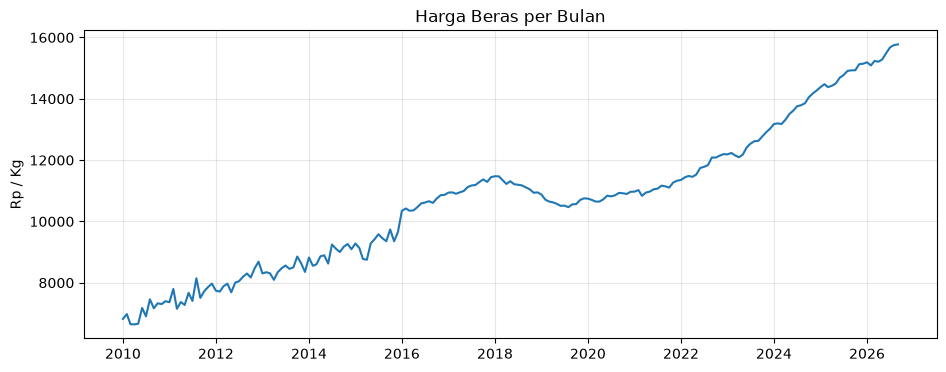

Harga_Beras_Rp_Kg                     1.00
Harga_Beras_Bulan_Sebelumnya_Rp_Kg    1.00
Harga_Gabah_GKG_Rp_Kg                 0.97
Harga_Gabah_GKP_Rp_Kg                 0.97
Tahun                                 0.96
Kurs_Rupiah_USD                       0.95
Harga_BBM_Rp_Liter                    0.95
Stok_Beras_Ton                        0.92
Produksi_Padi_Ton                     0.05
Bulan                                 0.03
Curah_Hujan_mm                        0.03
Luas_Panen_Ha                        -0.02
Name: Harga_Beras_Rp_Kg, dtype: float64

In [3]:
plt.figure(figsize=(11, 4))
plt.plot(df["Tanggal"], df[TARGET])
plt.title("Harga Beras per Bulan")
plt.ylabel("Rp / Kg")
plt.grid(alpha=0.3)
plt.show()

df.select_dtypes("number").corr()[TARGET].sort_values(ascending=False).round(2)

## 4. Feature Engineering

In [4]:
# Bulan siklis (Desember dekat dengan Januari)
df["Bulan_sin"] = np.sin(2 * np.pi * df["Bulan"] / 12)
df["Bulan_cos"] = np.cos(2 * np.pi * df["Bulan"] / 12)

# Musim -> one-hot
df = pd.concat([df, pd.get_dummies(df["Musim"], prefix="Musim", dtype=int)], axis=1)

# Fitur dari harga bulan-bulan sebelumnya (tanpa kebocoran data)
df["Harga_Sebelumnya"] = df[LAG]
df["Selisih_2_Bulan"] = df[LAG] - df[TARGET].shift(2)
df["Rata2_3_Bulan"] = df[TARGET].shift(1).rolling(3).mean()
df["Rasio_Gabah_GKG_ke_Beras"] = df["Harga_Gabah_GKG_Rp_Kg"] / df[LAG]

df = df.dropna().reset_index(drop=True)

fitur = [
    "Bulan_sin", "Bulan_cos",
    "Curah_Hujan_mm", "Luas_Panen_Ha", "Produksi_Padi_Ton",
    "Harga_Gabah_GKP_Rp_Kg", "Harga_Gabah_GKG_Rp_Kg",
    "Stok_Beras_Ton", "Stok_Tersedia",
    "Harga_BBM_Rp_Liter", "Kurs_Rupiah_USD",
    "Harga_Sebelumnya", "Selisih_2_Bulan", "Rata2_3_Bulan",
    "Rasio_Gabah_GKG_ke_Beras",
] + [c for c in df.columns if c.startswith("Musim_")]

print(len(fitur), "fitur:", fitur)

18 fitur: ['Bulan_sin', 'Bulan_cos', 'Curah_Hujan_mm', 'Luas_Panen_Ha', 'Produksi_Padi_Ton', 'Harga_Gabah_GKP_Rp_Kg', 'Harga_Gabah_GKG_Rp_Kg', 'Stok_Beras_Ton', 'Stok_Tersedia', 'Harga_BBM_Rp_Liter', 'Kurs_Rupiah_USD', 'Harga_Sebelumnya', 'Selisih_2_Bulan', 'Rata2_3_Bulan', 'Rasio_Gabah_GKG_ke_Beras', 'Musim_Hujan', 'Musim_Kemarau', 'Musim_Pancaroba']


## 5. Target & Split Berdasarkan Waktu

Target berupa **log-return** (perubahan harga terhadap bulan lalu). Model berbasis pohon tidak bisa memprediksi di luar rentang data latih, sehingga memprediksi harga mentah pada data uji (harga tertinggi) akan "mentok".

In [7]:
y_ret = np.log(df[TARGET] / df[LAG])
X = df[fitur]

n_uji = int(len(df) * UJI_PERSEN)
n_latih = len(df) - n_uji

X_latih, X_uji = X.iloc[:n_latih], X.iloc[n_latih:]
y_latih, y_uji = y_ret.iloc[:n_latih], y_ret.iloc[n_latih:]
harga_asli_uji = df[TARGET].iloc[n_latih:].values
harga_lalu_uji = df[LAG].iloc[n_latih:].values
tanggal_uji = df["Tanggal"].iloc[n_latih:]

print(f"Data latih : {n_latih} baris ({df['Tanggal'].iloc[0].date()} - {df['Tanggal'].iloc[n_latih-1].date()})")
print(f"Data uji   : {n_uji} baris ({tanggal_uji.iloc[0].date()} - {tanggal_uji.iloc[-1].date()})")


def ke_harga(pred_return, harga_lalu):
    return harga_lalu * np.exp(pred_return)


def evaluasi(nama, harga_pred):
    return {
        "Model": nama,
        "MAE (Rp)": mean_absolute_error(harga_asli_uji, harga_pred),
        "RMSE (Rp)": np.sqrt(mean_squared_error(harga_asli_uji, harga_pred)),
        "MAPE (%)": np.mean(np.abs((harga_asli_uji - harga_pred) / harga_asli_uji)) * 100,
        "R2": r2_score(harga_asli_uji, harga_pred),
    }

Data latih : 159 baris (2010-04-01 - 2023-06-01)
Data uji   : 39 baris (2023-07-01 - 2026-09-01)


## 6. Pelatihan & Tuning Model

In [8]:
tscv = TimeSeriesSplit(n_splits=5)

kandidat = {
    "Ridge Regression": (
        Pipeline([("scaler", StandardScaler()), ("m", Ridge())]),
        {"m__alpha": [0.1, 1, 10, 100]},
    ),
    "Random Forest": (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {"n_estimators": [200, 400], "max_depth": [3, 5, None], "min_samples_leaf": [1, 3, 5]},
    ),
    "Gradient Boosting": (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {"n_estimators": [100, 300], "learning_rate": [0.03, 0.1], "max_depth": [2, 3]},
    ),
}

hasil, model_terlatih, prediksi = [], {}, {}

# Baseline: harga bulan ini = harga bulan lalu. Model harus mengalahkan ini.
hasil.append(evaluasi("Baseline (harga bulan lalu)", harga_lalu_uji))

for nama, (model, grid) in kandidat.items():
    print(f"Melatih {nama} ...")
    gs = GridSearchCV(model, grid, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
    gs.fit(X_latih, y_latih)
    model_terlatih[nama] = gs.best_estimator_
    prediksi[nama] = ke_harga(gs.predict(X_uji), harga_lalu_uji)
    hasil.append(evaluasi(nama, prediksi[nama]))
    print("   parameter terbaik:", gs.best_params_)

Melatih Ridge Regression ...
   parameter terbaik: {'m__alpha': 100}
Melatih Random Forest ...
   parameter terbaik: {'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 200}
Melatih Gradient Boosting ...
   parameter terbaik: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100}


## 7. Evaluasi pada Data Uji

In [9]:
tabel = pd.DataFrame(hasil).set_index("Model").round(2)
nama_terbaik = tabel.drop(index="Baseline (harga bulan lalu)")["MAE (Rp)"].idxmin()
print("Model terbaik:", nama_terbaik)
tabel

Model terbaik: Gradient Boosting


,MAE (Rp),RMSE (Rp),MAPE (%),R2
Model,,,,
Baseline (harga bulan lalu),98.56,115.03,0.70,0.99
Ridge Regression,88.46,104.67,0.62,0.99
Random Forest,79.98,95.26,0.56,0.99
Gradient Boosting,74.44,89.02,0.52,0.99


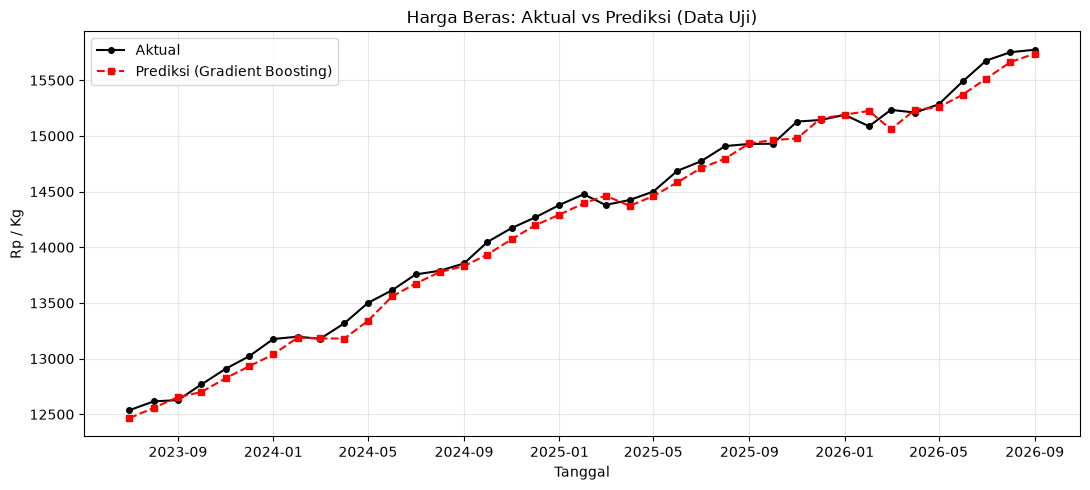

In [10]:
plt.figure(figsize=(11, 5))
plt.plot(tanggal_uji, harga_asli_uji, "k-o", label="Aktual", markersize=4)
plt.plot(tanggal_uji, prediksi[nama_terbaik], "r--s", label=f"Prediksi ({nama_terbaik})", markersize=4)
plt.title("Harga Beras: Aktual vs Prediksi (Data Uji)")
plt.xlabel("Tanggal")
plt.ylabel("Rp / Kg")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FOLDER_OUTPUT, "aktual_vs_prediksi.png"), dpi=150)
plt.show()

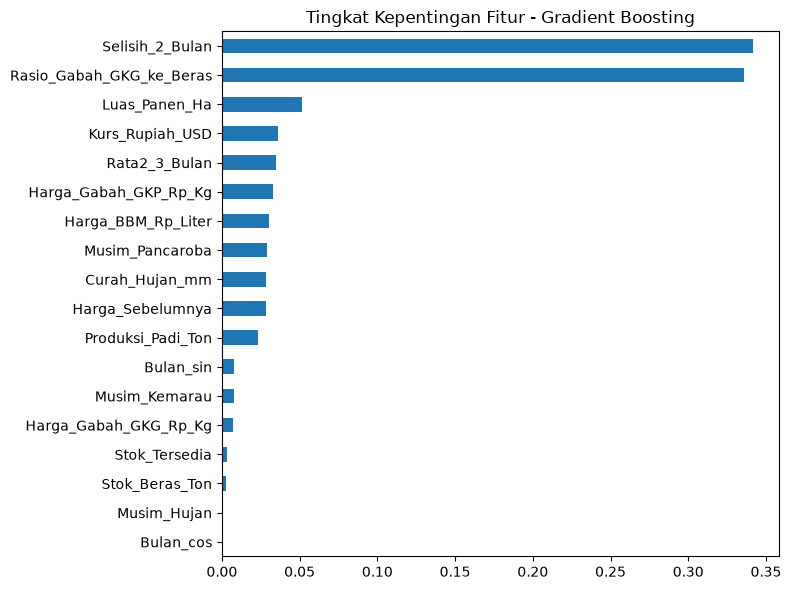

In [11]:
terbaik = model_terlatih[nama_terbaik]
estimator = terbaik.named_steps["m"] if hasattr(terbaik, "named_steps") else terbaik

if hasattr(estimator, "feature_importances_"):
    imp = pd.Series(estimator.feature_importances_, index=fitur).sort_values()
    plt.figure(figsize=(8, 6))
    imp.plot(kind="barh")
    plt.title(f"Tingkat Kepentingan Fitur - {nama_terbaik}")
    plt.tight_layout()
    plt.savefig(os.path.join(FOLDER_OUTPUT, "feature_importance.png"), dpi=150)
    plt.show()

## 8. Latih Ulang dengan Semua Data & Simpan Model

In [14]:
final_model = model_terlatih[nama_terbaik]
final_model.fit(X, y_ret)

joblib.dump({"model": final_model, "fitur": fitur}, os.path.join(FOLDER_OUTPUT, "model_harga_beras.joblib"))
tabel.to_csv(os.path.join(FOLDER_OUTPUT, "hasil_evaluasi.csv"))
print("Model & hasil disimpan di:", FOLDER_OUTPUT)

Model & hasil disimpan di: D:\DATASET\hasil_model


## 9. Prediksi Harga Bulan Depan

Isi nilai pada sel di bawah dengan data terbaru Anda. Untuk memprediksi bulan depan, curah hujan, kurs, harga gabah, dan seterusnya perlu diisi dengan nilai aktual atau perkiraan Anda sendiri.

In [ ]:
def prediksi_harga(bulan, musim, curah_hujan, luas_panen, produksi_padi,
                   gabah_gkp, gabah_gkg, stok_beras, harga_bbm, kurs,
                   harga_bulan_lalu, harga_2_bulan_lalu, harga_3_bulan_lalu):
    """Prediksi harga beras (Rp/kg). musim: 'Hujan', 'Kemarau', atau 'Pancaroba'."""
    p = joblib.load(os.path.join(FOLDER_OUTPUT, "model_harga_beras.joblib"))
    baris = {
        "Bulan_sin": np.sin(2 * np.pi * bulan / 12),
        "Bulan_cos": np.cos(2 * np.pi * bulan / 12),
        "Curah_Hujan_mm": curah_hujan,
        "Luas_Panen_Ha": luas_panen,
        "Produksi_Padi_Ton": produksi_padi,
        "Harga_Gabah_GKP_Rp_Kg": gabah_gkp,
        "Harga_Gabah_GKG_Rp_Kg": gabah_gkg,
        "Stok_Beras_Ton": stok_beras,
        "Stok_Tersedia": int(stok_beras > 1),
        "Harga_BBM_Rp_Liter": harga_bbm,
        "Kurs_Rupiah_USD": kurs,
        "Harga_Sebelumnya": harga_bulan_lalu,
        "Selisih_2_Bulan": harga_bulan_lalu - harga_2_bulan_lalu,
        "Rata2_3_Bulan": np.mean([harga_bulan_lalu, harga_2_bulan_lalu, harga_3_bulan_lalu]),
        "Rasio_Gabah_GKG_ke_Beras": gabah_gkg / harga_bulan_lalu,
    }
    for m in ["Hujan", "Kemarau", "Pancaroba"]:
        baris[f"Musim_{m}"] = int(musim == m)
    x = pd.DataFrame([baris])[p["fitur"]]
    return float(harga_bulan_lalu * np.exp(p["model"].predict(x)[0]))


terakhir = df.iloc[-1]
hasil_prediksi = prediksi_harga(
    bulan=10, musim="Kemarau", curah_hujan=80, luas_panen=900000,
    produksi_padi=5000000, gabah_gkp=7050, gabah_gkg=7760,
    stok_beras=4300000, harga_bbm=10010, kurs=17700,
    harga_bulan_lalu=terakhir[TARGET],
    harga_2_bulan_lalu=terakhir[LAG],
    harga_3_bulan_lalu=df[TARGET].iloc[-3],
)
print(f"Prediksi harga beras bulan depan: Rp {hasil_prediksi:,.0f} / kg")

Prediksi harga beras bulan depan: Rp 15,833 / kg
